In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import numpy as np
import os
from pathlib import Path

In [2]:
con = duckdb.connect(':memory:')

In [11]:

VM_HARDWARE = "/Users/biancachiusano/Desktop/uva/thesis/Thesis/datasets/cloud_energy_consumption/vms/2024-12-14T000000Z_2025-04-13T235959Z/vms.csv"
con.query(f"""CREATE OR REPLACE TABLE vmhardware AS SELECT * FROM '{VM_HARDWARE}'""")

In [26]:
vm_df = con.execute("""
                    CREATE OR REPLACE VIEW vm_data AS
                    SELECT *
                    FROM read_csv_auto('/Users/biancachiusano/Desktop/uva/thesis/Thesis/datasets/cloud_energy_consumption/nodes-vms/2024-12-14T000000Z_2025-04-13T235959Z/**/*.csv',
                                    filename=false,
                                    union_by_name=true)
                """)

In [6]:
con.query(""" SELECT * FROM vm_data LIMIT 5""").show()

┌──────────────────────────┬──────────┬─────────────────┬──────────────────┬─────────────────────────────────┐
│        timestamp         │  vm_id   │ hypervisor_name │ hypervisor_group │ scaphandre_vm_power_total_watts │
│ timestamp with time zone │ varchar  │     varchar     │     varchar      │             double              │
├──────────────────────────┼──────────┼─────────────────┼──────────────────┼─────────────────────────────────┤
│ 2025-01-16 09:06:00+01   │ 88a350ca │ 21e01022        │ 11cdff15         │                            3.55 │
│ 2025-01-16 09:09:00+01   │ 88a350ca │ 21e01022        │ 11cdff15         │                             3.0 │
│ 2025-01-16 09:12:00+01   │ 88a350ca │ 21e01022        │ 11cdff15         │                            2.46 │
│ 2025-01-16 09:15:00+01   │ 88a350ca │ 21e01022        │ 11cdff15         │                            2.64 │
│ 2025-01-16 09:18:00+01   │ 88a350ca │ 21e01022        │ 11cdff15         │                            3.99 │
└

## VM Hardware 
Hardware characteristics and information about the virtual machines in the IFCA Cloud infrastructure, including their user and project information.

The `vm_id` of the virtual machines in this dataset is equivalent to the `vm_id` of the virtual machines in the "Virtual Machines energy consumption metrics" dataset. The `project_id` and `user_id` of the virtual machines in this dataset are used to identify the project and user associated with them.

**Shape**: (611, 8)
**Identifiers:**
- `vm_id`: The ID of the virtual machine. (STRING)
- `project_id`: The ID of the project. (STRING)
- `user_id`: The ID of the user. A user can belong to multiple projects. (STRING)
    
**Virtual Machines Characteristics:**
- `image_ref`: The ID of the image. The images are used to create the virtual machines.(STRING)
- `vcpus`: Number of virtual CPUs in the virtual machine.
- `memory_MB`: Amount of memory in MB in the virtual machine.
- `root_GB`: Size of the root disk in GB in the virtual machine.
- `ephemeral_GB`: Size of the ephemeral disk in GB in the virtual machine.

In [12]:
# Missing values in vmhardware
con.query("""SELECT 
            COUNT(*) - COUNT(vcpus) AS vcpus_null, 
            COUNT(*) - COUNT(memory_mb) AS memory_mb_null, 
            COUNT(*) - COUNT(root_gb) AS root_gb_null,
            COUNT(*) - COUNT(ephemeral_gb) AS ephemeral_gb_null
            FROM vmhardware""").show()

┌────────────┬────────────────┬──────────────┬───────────────────┐
│ vcpus_null │ memory_mb_null │ root_gb_null │ ephemeral_gb_null │
│   int64    │     int64      │    int64     │       int64       │
├────────────┼────────────────┼──────────────┼───────────────────┤
│          0 │              0 │            0 │                26 │
└────────────┴────────────────┴──────────────┴───────────────────┘



**Observation:** Only `ephemeral_gb` has missing values — 26 out of 611 rows. Inspection of the raw data shows these NULLs correspond to VMs where ephemeral disk was not configured. All other columns are fully populated.
#### Counts 
How many unique: 
- Virtual Machines
- Users
- Projects
- Images

In [13]:
con.query("""
    SELECT 
        COUNT(*) AS total_vms,
        COUNT(DISTINCT vm_id) AS unique_vms,
        COUNT(DISTINCT project_id) AS unique_projects,
        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(DISTINCT image_ref) AS unique_images
    FROM vmhardware
""").show()

┌───────────┬────────────┬─────────────────┬──────────────┬───────────────┐
│ total_vms │ unique_vms │ unique_projects │ unique_users │ unique_images │
│   int64   │   int64    │      int64      │    int64     │     int64     │
├───────────┼────────────┼─────────────────┼──────────────┼───────────────┤
│       611 │        611 │              55 │           61 │           124 │
└───────────┴────────────┴─────────────────┴──────────────┴───────────────┘



**Observation:** The dataset contains **611 unique VMs** across **55 projects** and **61 users**, using **124 distinct base images**. The many-to-one relationship between users and projects suggests that most projects are single-user, with a small number of shared collaborative projects. The 124 distinct images indicates a diverse range of workloads rather than a standardised deployment environment.
#### VM Resource Distributions
vcpus, memory, disk sizes

In [14]:
con.query("""
    SELECT
        MIN(vcpus), MAX(vcpus), AVG(vcpus), MEDIAN(vcpus),
        MIN(memory_MB), MAX(memory_MB), AVG(memory_MB),
        MIN(root_GB), MAX(root_GB), AVG(root_GB),
        MIN(ephemeral_GB), MAX(ephemeral_GB), AVG(ephemeral_GB)
    FROM vmhardware
""").show()

┌────────────┬────────────┬───────────────────┬───────────────┬────────────────┬────────────────┬───────────────────┬──────────────┬──────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┐
│ min(vcpus) │ max(vcpus) │    avg(vcpus)     │ median(vcpus) │ min(memory_MB) │ max(memory_MB) │  avg(memory_MB)   │ min(root_GB) │ max(root_GB) │   avg(root_GB)    │ min(ephemeral_GB) │ max(ephemeral_GB) │ avg(ephemeral_GB) │
│   double   │   double   │      double       │    double     │     double     │     double     │      double       │    double    │    double    │      double       │      double       │      double       │      double       │
├────────────┼────────────┼───────────────────┼───────────────┼────────────────┼────────────────┼───────────────────┼──────────────┼──────────────┼───────────────────┼───────────────────┼───────────────────┼───────────────────┤
│        1.0 │   192000.0 │ 809.3698854337152 │           8.0 │           10.0 │       3

#### Users
Checking to see how many VMs each user runs and whether some users appear more frequently then others

In [15]:
con.query("""
    SELECT user_id, COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY user_id
    ORDER BY vm_count DESC
    LIMIT 5
""").show()

┌──────────┬──────────┐
│ user_id  │ vm_count │
│ varchar  │  int64   │
├──────────┼──────────┤
│ 0fb4c56f │      102 │
│ 7f7c4759 │       72 │
│ 7190ddfa │       46 │
│ f098d7fe │       43 │
│ 687850f0 │       30 │
└──────────┴──────────┘



How many projects user (with high vm count) belongs to 

In [16]:
# Sorted by vm_count
con.query("""
    SELECT user_id, COUNT(DISTINCT project_id) AS project_count, COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY user_id
    ORDER BY vm_count DESC
    LIMIT 10
""").show()

┌──────────┬───────────────┬──────────┐
│ user_id  │ project_count │ vm_count │
│ varchar  │     int64     │  int64   │
├──────────┼───────────────┼──────────┤
│ 0fb4c56f │             3 │      102 │
│ 7f7c4759 │             2 │       72 │
│ 7190ddfa │             1 │       46 │
│ f098d7fe │             1 │       43 │
│ 687850f0 │             1 │       30 │
│ 17de5058 │             2 │       27 │
│ a16f591f │             6 │       26 │
│ 756b77ce │             3 │       20 │
│ 1970b804 │             8 │       17 │
│ 39786247 │             8 │       17 │
└──────────┴───────────────┴──────────┘
  10 rows                   3 columns



**Observation:** VM ownership is highly concentrated. The top user (`0fb4c56f`) alone operates **102 VMs** (17%) across 3 projects. The top 4 users account for over 40% of all VMs. This concentration is important for energy attribution: a small number of users drive a disproportionate share of infrastructure load.

In [17]:
# Sorted by project_count
con.query("""
    SELECT user_id, COUNT(DISTINCT project_id) AS project_count, COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY user_id
    ORDER BY project_count DESC
    LIMIT 10
""").show()

┌──────────┬───────────────┬──────────┐
│ user_id  │ project_count │ vm_count │
│ varchar  │     int64     │  int64   │
├──────────┼───────────────┼──────────┤
│ 39786247 │             8 │       17 │
│ 1970b804 │             8 │       17 │
│ 167938a6 │             6 │       16 │
│ a16f591f │             6 │       26 │
│ 0fb4c56f │             3 │      102 │
│ 756b77ce │             3 │       20 │
│ 1a324c91 │             3 │        6 │
│ a878bb6a │             3 │       11 │
│ 93563d4d │             3 │        9 │
│ 17de5058 │             2 │       27 │
└──────────┴───────────────┴──────────┘
  10 rows                   3 columns



**Observation:** Users with the highest project count (up to 8 projects) tend to have moderate VM counts (17), suggesting they are infrastructure or admin users operating across many projects with lightweight footprints. In contrast, the highest VM-count users (`0fb4c56f`: 102 VMs, `7f7c4759`: 72 VMs) are concentrated in fewer projects, suggesting dedicated large-scale workloads.
#### Projects
Resource consumption per project 

In [18]:
con.query("""
            SELECT 
                project_id,
                COUNT(*) AS vm_count,
                SUM(vcpus) AS total_vcpus,
                SUM(memory_MB) / 1024 AS total_memory_GB,
                SUM(root_GB) AS total_root_GB,
                COUNT(DISTINCT user_id) AS user_count
            FROM vmhardware
            GROUP BY project_id
            ORDER BY vm_count DESC
            LIMIT 5
        """).show()


┌────────────┬──────────┬─────────────┬─────────────────┬───────────────┬────────────┐
│ project_id │ vm_count │ total_vcpus │ total_memory_GB │ total_root_GB │ user_count │
│  varchar   │  int64   │   double    │     double      │    double     │   int64    │
├────────────┼──────────┼─────────────┼─────────────────┼───────────────┼────────────┤
│ 43d3e415   │      162 │     15104.0 │     36339.84375 │       23220.0 │          3 │
│ 7d4a4a5a   │       68 │     31229.0 │  2919.462890625 │        3670.0 │         14 │
│ 906147a9   │       47 │       181.0 │    479.98046875 │         920.0 │          2 │
│ c5e1c75e   │       43 │       458.0 │    1022.4609375 │        1180.0 │          1 │
│ a99b2934   │       30 │       670.0 │   1218.26171875 │       13350.0 │          1 │
└────────────┴──────────┴─────────────┴─────────────────┴───────────────┴────────────┘



**Observation:** Resource consumption is dominated by a small number of projects. Project `43d3e415` leads in VM count (162 VMs) and memory (36 TB), but project `7d4a4a5a` leads in total vCPUs (31,229) despite having fewer VMs (68), implying it runs very large compute-intensive instances. Project `e7f3706a` is a notable outlier: 15 VMs but 20,018 total vCPUs and only 42 GB total memory.


#### Images
Which images are used the most 

In [19]:

con.query("""
    SELECT image_ref, COUNT(*) AS usage_count
    FROM vmhardware
    GROUP BY image_ref
    ORDER BY usage_count DESC
    LIMIT 5
""").show()

┌───────────┬─────────────┐
│ image_ref │ usage_count │
│  varchar  │    int64    │
├───────────┼─────────────┤
│ 37f08a62  │          63 │
│ ea4ccc2c  │          43 │
│ ff7564db  │          32 │
│ 8d324fd3  │          29 │
│ eafb3cc8  │          24 │
└───────────┴─────────────┘



In [20]:
# Common resource combinations 
con.query("""
    SELECT vcpus, memory_MB, root_GB, COUNT(*) AS count
    FROM vmhardware
    GROUP BY vcpus, memory_MB, root_GB
    ORDER BY count DESC
    LIMIT 5
""").show()

┌────────┬───────────┬─────────┬───────┐
│ vcpus  │ memory_mb │ root_gb │ count │
│ double │  double   │ double  │ int64 │
├────────┼───────────┼─────────┼───────┤
│    4.0 │   11000.0 │    20.0 │   102 │
│  128.0 │  370000.0 │   300.0 │    65 │
│    1.0 │    2000.0 │    10.0 │    53 │
│   48.0 │   94000.0 │    30.0 │    48 │
│    2.0 │    5000.0 │    10.0 │    46 │
└────────┴───────────┴─────────┴───────┘



In [21]:
#### Ephermal Disk Usage
# How many VMs use ephemeral storage vs none?
con.query("""
    SELECT 
        ephemeral_GB > 0 AS uses_ephemeral,
        COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY uses_ephemeral
""").show()

┌────────────────┬──────────┐
│ uses_ephemeral │ vm_count │
│    boolean     │  int64   │
├────────────────┼──────────┤
│ false          │      352 │
│ NULL           │       26 │
│ true           │      233 │
└────────────────┴──────────┘



In [ ]:
# When do they start and stop?
# How many vms per node and per node group?
# How many vms are active at any given time?
# How does the number of active vms correlate with energy consumption?

# Maybe I should make a dataset with only active times 

In [22]:
vm_hardware = pd.read_csv(VM_HARDWARE)
vm_hardware.head()

,vm_id,user_id,project_id,image_ref,vcpus,memory_mb,root_gb,ephemeral_gb
0,6239bcf4,39786247,4ba6ce42,85ecdff4,32.0,60000.0,30.0,160.0
1,80458243,bd41a7e4,74dfdf00,cb92696e,1.0,2000.0,10.0,20.0
2,5d9f6237,7190ddfa,906147a9,78c5906a,4.0,7500.0,30.0,60.0
3,941785dc,1a324c91,f09054da,23658854,2.0,4000.0,10.0,100.0
4,fb856e0f,c1eb1c1c,f09054da,c015d680,4.0,7500.0,30.0,60.0


In [ ]:
# just checking that vm_id is unique to a user_id
vm_hardware.groupby("vm_id")["user_id"].nunique().max()

np.int64(1)

## Merging the two dataframes

In [27]:
con.execute("""
    CREATE OR REPLACE TABLE vm_merged AS
    SELECT 
        d.*, 
        h.*
    FROM vm_data d
    LEFT JOIN vmhardware h
    ON d.vm_id = h.vm_id
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [28]:
vm_merged = con.execute("SELECT * FROM vm_merged").df()
vm_merged.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,timestamp,vm_id,hypervisor_name,hypervisor_group,scaphandre_vm_power_total_watts,vm_id_1,user_id,project_id,image_ref,vcpus,memory_mb,root_gb,ephemeral_gb
0,2025-03-21 11:18:00+01:00,8269929d,3eb76848,11cdff15,0.00,8269929d,0fb4c56f,43d3e415,8d324fd3,48.0,94000.0,30.0,270.0
1,2025-03-21 11:21:00+01:00,8269929d,3eb76848,11cdff15,1.45,8269929d,0fb4c56f,43d3e415,8d324fd3,48.0,94000.0,30.0,270.0
2,2025-03-21 11:24:00+01:00,8269929d,3eb76848,11cdff15,0.07,8269929d,0fb4c56f,43d3e415,8d324fd3,48.0,94000.0,30.0,270.0
3,2025-03-21 11:27:00+01:00,8269929d,3eb76848,11cdff15,0.07,8269929d,0fb4c56f,43d3e415,8d324fd3,48.0,94000.0,30.0,270.0
4,2025-03-21 11:30:00+01:00,8269929d,3eb76848,11cdff15,0.07,8269929d,0fb4c56f,43d3e415,8d324fd3,48.0,94000.0,30.0,270.0


# VMs per node distribution

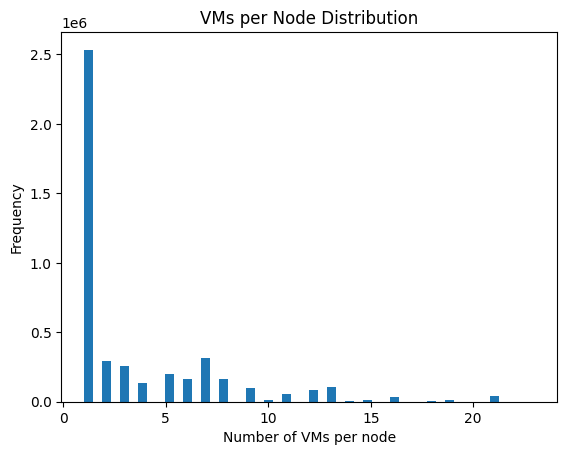

In [29]:
# count VMs per node per timestamp
vms_per_node = vm_merged.groupby(["timestamp", "hypervisor_name"])["vm_id"].nunique()

plt.figure()
plt.hist(vms_per_node, bins=50)
plt.xlabel("Number of VMs per node")
plt.ylabel("Frequency")
plt.title("VMs per Node Distribution")
plt.show()

# VMs per user distribution

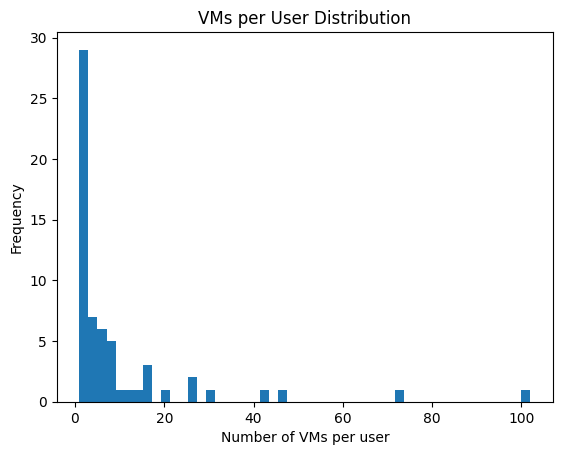

In [31]:
vms_per_user = vm_merged.groupby("user_id")["vm_id"].nunique()

plt.figure()
plt.hist(vms_per_user, bins=50)
plt.xlabel("Number of VMs per user")
plt.ylabel("Frequency")
plt.title("VMs per User Distribution")
plt.show()

so around 30 users have only one vm, there seems to be a user that has more than 100 vms

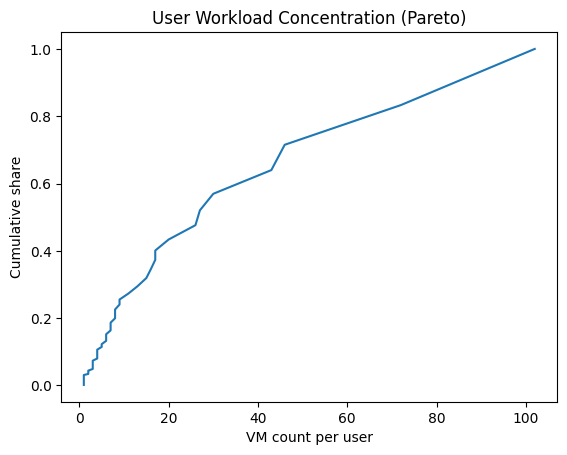

In [33]:
sorted_vms = np.sort(vms_per_user)
cum = np.cumsum(sorted_vms) / np.sum(sorted_vms)

plt.figure()
plt.plot(sorted_vms, cum)
plt.xlabel("VM count per user")
plt.ylabel("Cumulative share")
plt.title("User Workload Concentration (Pareto)")
plt.show()

# VM Lifetime / Stability

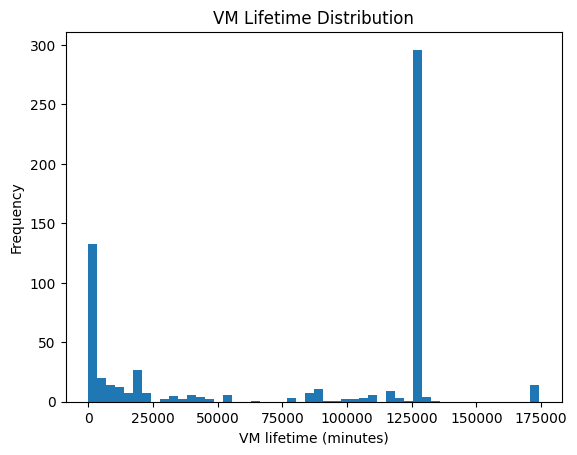

In [34]:
vm_lifetime = vm_merged.groupby("vm_id")["timestamp"].agg(["min", "max"])
vm_lifetime["lifetime_minutes"] = (
    vm_lifetime["max"] - vm_lifetime["min"]
).dt.total_seconds() / 60

plt.figure()
plt.hist(vm_lifetime["lifetime_minutes"], bins=50)
plt.xlabel("VM lifetime (minutes)")
plt.ylabel("Frequency")
plt.title("VM Lifetime Distribution")
plt.show()

175000 minutes is is approximately 121 days, 12 hours, and 40 minutes.

# Power consumption

In [35]:
# NaNs in scaphandre_vm_power_total_watts
vm_merged["scaphandre_vm_power_total_watts"].isna().sum()

np.int64(971896)

In [36]:
vm_merged.shape

(15942293, 13)

### VM Stability

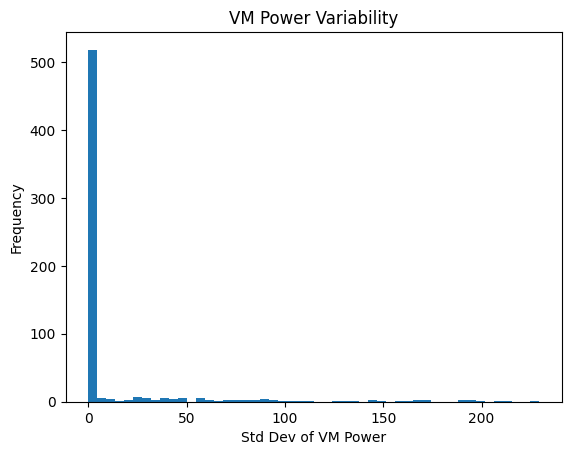

In [37]:
vm_variability = vm_merged.groupby("vm_id")["scaphandre_vm_power_total_watts"].std()

plt.figure()
plt.hist(vm_variability, bins=50)
plt.xlabel("Std Dev of VM Power")
plt.ylabel("Frequency")
plt.title("VM Power Variability")
plt.show()

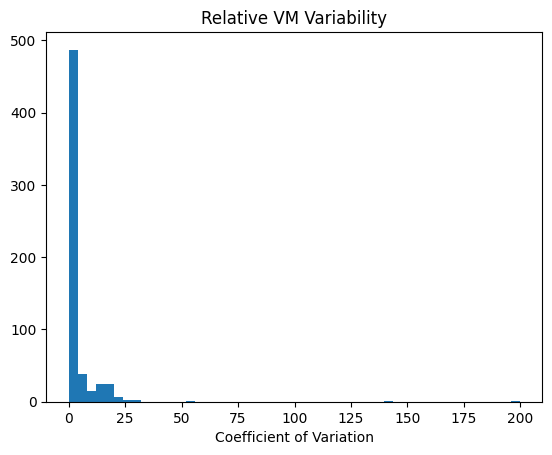

In [38]:
vm_mean = vm_merged.groupby("vm_id")["scaphandre_vm_power_total_watts"].mean()
cv = vm_variability / vm_mean  # coefficient of variation

plt.figure()
plt.hist(cv.dropna(), bins=50)
plt.xlabel("Coefficient of Variation")
plt.title("Relative VM Variability")
plt.show()

## Power vs vCPU scatter

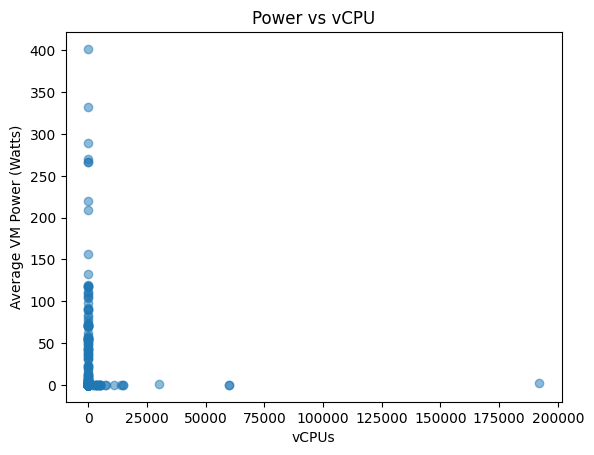

In [39]:
# aggregate per VM (mean values)
vm_stats = vm_merged.groupby("vm_id").agg({
    "scaphandre_vm_power_total_watts": "mean",
    "vcpus": "first"
}).dropna()

plt.figure()
plt.scatter(vm_stats["vcpus"], vm_stats["scaphandre_vm_power_total_watts"], alpha=0.5)
plt.xlabel("vCPUs")
plt.ylabel("Average VM Power (Watts)")
plt.title("Power vs vCPU")
plt.show()

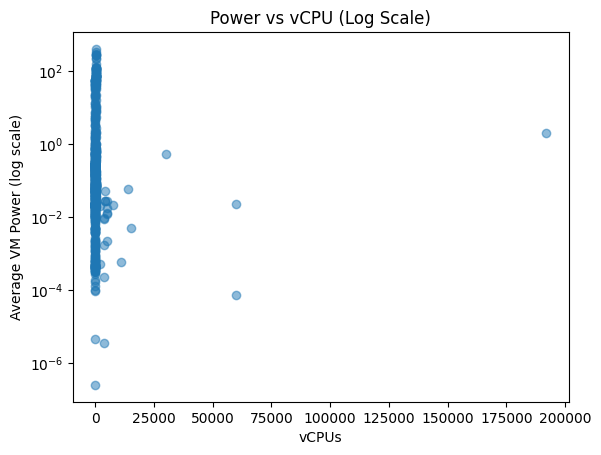

In [40]:
# log version
plt.figure()
plt.scatter(vm_stats["vcpus"], vm_stats["scaphandre_vm_power_total_watts"], alpha=0.5)
plt.yscale("log")
plt.xlabel("vCPUs")
plt.ylabel("Average VM Power (log scale)")
plt.title("Power vs vCPU (Log Scale)")
plt.show()

In [41]:
corr = vm_stats.corr()
print(corr)

                                 scaphandre_vm_power_total_watts     vcpus
scaphandre_vm_power_total_watts                         1.000000 -0.021504
vcpus                                                  -0.021504  1.000000
